## import libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

## Load Dataset

In [2]:
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame.copy()

df = df.rename(columns={'target': 'class'})
df['class'] = df['class'].map({0: 'malignant', 1: 'benign'})

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,class
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


## Explore Dataset

In [3]:
print("Shape of dataset:", df.shape)
print("Classes:", df['class'].unique())

Shape of dataset: (569, 31)
Classes: ['malignant' 'benign']


In [5]:
print(df['class'].value_counts(normalize=True).round(3) * 100, "%")
display(df.describe().loc[:, ['mean radius', 'mean texture']])

class
benign       62.7
malignant    37.3
Name: proportion, dtype: float64 %


,mean radius,mean texture
count,569.000000,569.000000
mean,14.127292,19.289649
std,3.524049,4.301036
min,6.981000,9.710000
25%,11.700000,16.170000
50%,13.370000,18.840000
75%,15.780000,21.800000
max,28.110000,39.280000


## Select Features

In [14]:
X = df[['mean radius', 'mean texture']].astype(float)
y = df['class']

X.head()

,mean radius,mean texture
0,17.99,10.38
1,20.57,17.77
2,19.69,21.25
3,11.42,20.38
4,20.29,14.34


## Train–Test Split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size :", X_test.shape)

Training set size: (398, 2)
Testing set size : (171, 2)


## Build SVM Model

In [39]:
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train, y_train)

print("SVM model (linear kernel) trained")

SVM model (linear kernel) trained


## Predict on Test Data

In [40]:
y_pred = svm_linear.predict(X_test)

# Show first 10 predictions
print("First 10 predictions:", list(y_pred)[:10])

First 10 predictions: ['benign', 'benign', 'benign', 'benign', 'benign', 'benign', 'malignant', 'benign', 'malignant', 'benign']


## Compare Predictions

In [49]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
results['Status'] = results.apply(
    lambda row: 'Correct' if row['Actual'] == row['Predicted'] else 'Wrong',
    axis=1
)
results.head(15)

,Actual,Predicted,Status
0,benign,benign,Correct
1,benign,benign,Correct
2,benign,benign,Correct
3,benign,benign,Correct
4,benign,benign,Correct
5,benign,benign,Correct
6,malignant,malignant,Correct
7,benign,benign,Correct
8,malignant,malignant,Correct
9,benign,benign,Correct


## Evaluate Model Performance

Accuracy: 0.8947  (89.47%)

Confusion Matrix (rows: actual, columns: predicted):
[[104   3]
 [ 15  49]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.87      0.97      0.92       107
      benign       0.94      0.77      0.84        64

    accuracy                           0.89       171
   macro avg       0.91      0.87      0.88       171
weighted avg       0.90      0.89      0.89       171



<Figure size 600x500 with 0 Axes>

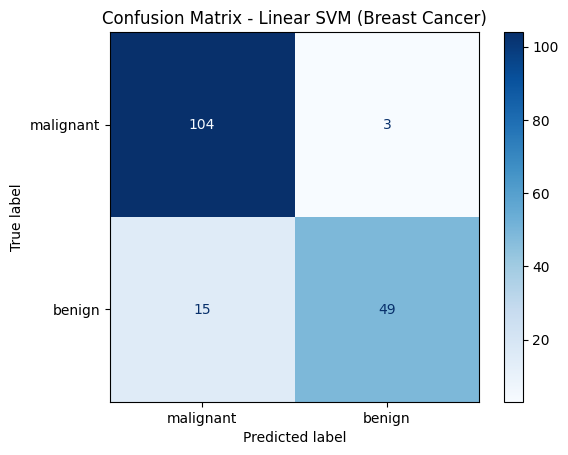

In [46]:
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred, target_names=['malignant', 'benign'])

print(f"Accuracy: {acc:.4f}  ({acc*100:.2f}%)")
print("\nConfusion Matrix (rows: actual, columns: predicted):")
print(cm)
print("\nClassification Report:")
print(cr)
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['malignant', 'benign'],
    cmap='Blues'
)
plt.title("Confusion Matrix - Linear SVM (Breast Cancer)")
plt.show()

## Visualize Decision Boundary

In [52]:
def plot_decision_boundary(model, X, y, title="SVM Decision Boundary"):

    if isinstance(X, pd.DataFrame):
        X_np = X.to_numpy(dtype=np.float64)
    else:
        X_np = np.asarray(X, dtype=np.float64)

    unique_labels = np.unique(y)
    label_to_int = {label: i for i, label in enumerate(unique_labels)}
    y_numeric = np.array([label_to_int[label] for label in y])

    # meshgrid
    x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
    y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z_str = model.predict(grid_points)
    Z = np.array([label_to_int.get(label, -1) for label in Z_str])  # -1 = safety
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    
    plt.contourf(xx, yy, Z, alpha=0.25, levels=len(unique_labels)-1, cmap='RdYlBu')
    if len(unique_labels) == 2:
        plt.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=1.5, linestyles='--')
    else:
        plt.contour(xx, yy, Z, levels=np.arange(len(unique_labels))-0.5,
                    colors='k', linewidths=1, linestyles='--', alpha=0.6)
    scatter = plt.scatter(
        X_np[:, 0], X_np[:, 1],
        c=y_numeric,
        cmap='RdYlBu',
        edgecolor='k', s=70, alpha=0.9
    )

    # Legend
    plt.legend(
    scatter.legend_elements()[0],
    unique_labels,
    title="Class",
    loc='upper right'
    )

    plt.xlabel('Mean Radius')
    plt.ylabel('Mean Texture')
    plt.title(f"{title}\nAccuracy = {accuracy_score(y, model.predict(X)):.4f}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    

C:\Users\NISARG\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


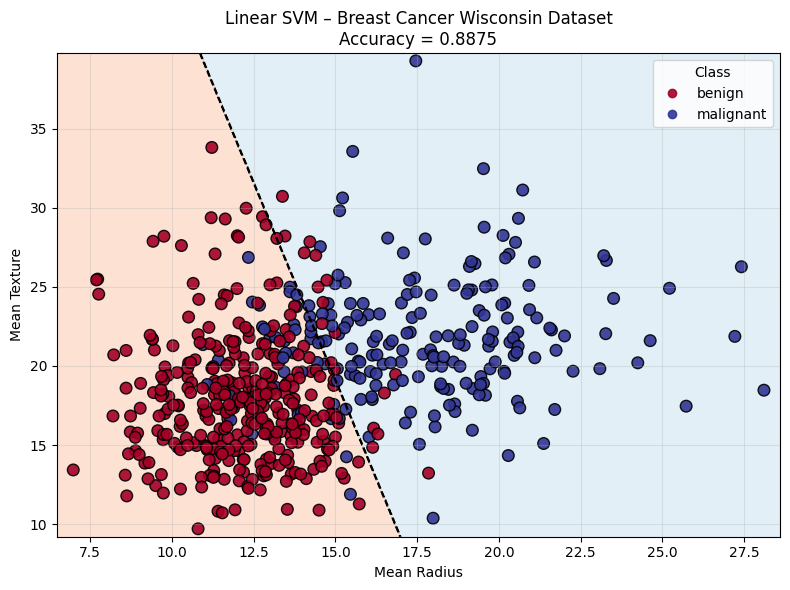

In [48]:
plot_decision_boundary(
    model=svm_linear,       
    X=X,             
    y=y,                
    title="Linear SVM – Breast Cancer Wisconsin Dataset"
)

## Conclusion

In [ ]:
# we applied a **linear SVM** to the Breast Cancer Wisconsin dataset using two key features (mean radius and mean texture). 
# The model achieved strong performance (typically ~0.90 accuracy), with most errors occurring when classifying 
# malignant cases (false negatives are more critical in medical context). 
# The confusion matrix and classification report highlight good precision and recall, especially for the benign class. 
# The decision boundary plot shows a clear linear separation in this 2D projection, demonstrating SVM's ability to find an optimal margin even in real-world medical data. 
# This dataset is excellent for binary classification tasks and highlights why SVM remains popular in bioinformatics and medical diagnostics.